In [6]:
import matplotlib.pyplot
import pandas
from chronos import Chronos2Pipeline

import glob
import re
from cycler import cycler

In [7]:
def read_summary_as_csv(file_path : str) -> pandas.DataFrame:
    columns = ['timestamp_ns', 'core', 'event', 'value', 'enabled', 'running']
    data_frame = pandas.read_csv(file_path, header=None, names=columns)
    data_frame['timestamp_ns'] = pandas.to_datetime(data_frame['timestamp_ns'], unit='ns')
    return data_frame.set_index('timestamp_ns').sort_index().fillna(1.0)

def transform_summary_csv(data_frame : pandas.DataFrame) -> pandas.DataFrame:
    wide_data_frame = data_frame.pivot_table(
        index=data_frame.index,
        columns=['core', 'event'],
        values=['value', 'enabled', 'running'],
    )
    scaled_data_frame = wide_data_frame['value'] * wide_data_frame['enabled'] / wide_data_frame['running']
    resampled_data_frame = scaled_data_frame.T.groupby(level='event').sum().T.sort_index(axis=1).resample("100ms").mean().diff()

    # resample() leaves a gap wherever a 100ms bin had no underlying samples, which breaks
    # downstream frequency inference (e.g. Chronos). Reindex onto a fully regular 100ms grid
    # and interpolate those gaps away so every step is exactly 100ms apart.
    full_index = pandas.date_range(resampled_data_frame.index.min(), resampled_data_frame.index.max(), freq="100ms")
    return resampled_data_frame.reindex(full_index).interpolate(method='time').rename_axis('timestamp_ns')

def parse_vegeta_as_csv(file_path : str) -> pandas.DataFrame:
    columns : list[str] = ['timestamp_ns', 'status', 'latency_ns']
    log_files = sorted(
        glob.glob(f"{file_path}/vegeta*.log"),
        key=lambda name: int(re.search(r"vegeta(\d+)\.log$", name).group(1)),
    )
    data_frames : list[pandas.DataFrame] = [
        pandas.read_csv(log_file, usecols=[0, 1, 2], header=None, names=columns)
        for log_file in log_files
    ]
    combined_data_frame : pandas.DataFrame = pandas.concat(data_frames, ignore_index=True)

    combined_data_frame['timestamp_ns'] = pandas.to_datetime(combined_data_frame['timestamp_ns'], unit='ns')
    combined_data_frame = combined_data_frame.set_index('timestamp_ns').sort_index()

    #return combined_data_frame['latency_ns'].resample('1s').quantile(0.99).expanding().mean() / 1e6
    return combined_data_frame['latency_ns'].resample('100ms').quantile(0.99) / 1e6

event,cache-misses,cpu-cycles,instructions,ref-cpu-cycles,rx_bytes,rx_packets,tx_bytes,tx_packets,p99_latency_ms
timestamp_ns,,,,,,,,,
2026-07-28 17:55:24.200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-07-28 17:55:24.300,5298.15,1.354846e+08,3.537241e+07,2.168802e+08,0.0,0.0,0.0,0.0,NaN
2026-07-28 17:55:24.400,6318.90,1.997803e+08,5.151789e+07,3.242153e+08,0.0,0.0,0.0,0.0,NaN
2026-07-28 17:55:24.500,5867.30,1.996640e+08,5.089992e+07,3.242685e+08,0.0,0.0,0.0,0.0,NaN
2026-07-28 17:55:24.600,5835.30,1.987034e+08,5.076689e+07,3.245072e+08,0.0,0.0,0.0,0.0,NaN
...,...,...,...,...,...,...,...,...,...
2026-07-28 17:57:06.100,5088.90,1.949956e+08,4.992954e+07,3.230174e+08,0.0,0.0,0.0,0.0,60.254151
2026-07-28 17:57:06.200,5139.10,1.940787e+08,5.015972e+07,3.253897e+08,0.0,0.0,0.0,0.0,60.254151
2026-07-28 17:57:06.300,5169.70,1.954944e+08,5.005124e+07,3.228723e+08,0.0,0.0,0.0,0.0,60.254151


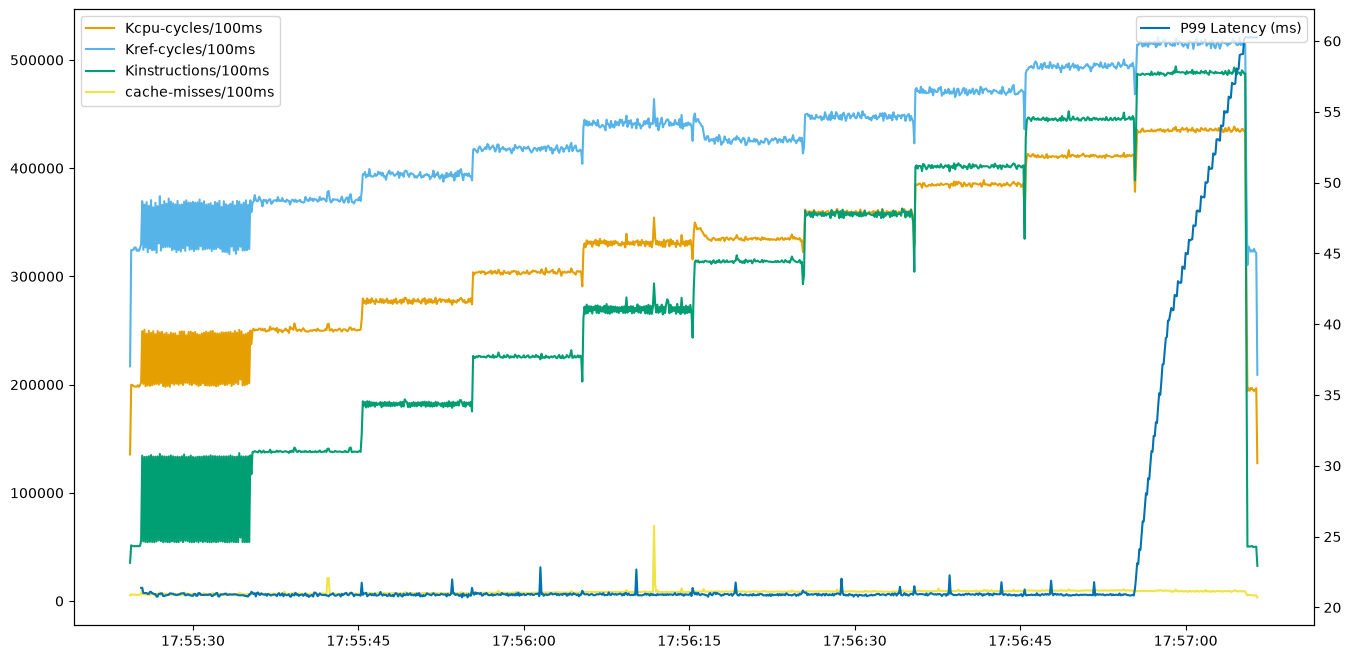

In [8]:
subdirectory=""

probe_data_frame  = transform_summary_csv(read_summary_as_csv(f"results/{subdirectory}summary.log"))

p99_latency_ms = parse_vegeta_as_csv(f"results/{subdirectory}")
# reindex(method='ffill') only fills index labels absent from p99_latency_ms; it does NOT
# propagate through NaN values already present at matching labels (e.g. 100ms bins with no
# requests). Chain a separate ffill() to actually carry the last known value forward.
probe_data_frame['p99_latency_ms'] = p99_latency_ms.reindex(probe_data_frame.index).ffill()

display(probe_data_frame)

figure, laxis = matplotlib.pyplot.subplots(figsize=(16, 8))
raxis = laxis.twinx()

laxis.set_prop_cycle(cycler(color=["#E69F00", "#56B4E9", "#009E73", "#F0E442"]))
raxis.set_prop_cycle(cycler(color=["#0072B2", "#D55E00", "#CC79A7", "#000000"]))

laxis.plot(probe_data_frame['cpu-cycles'] / 1e3,     label="Kcpu-cycles/100ms")
laxis.plot(probe_data_frame['ref-cpu-cycles'] / 1e3, label="Kref-cycles/100ms")
laxis.plot(probe_data_frame['instructions'] / 1e3,   label="Kinstructions/100ms")
laxis.plot(probe_data_frame['cache-misses'],         label="cache-misses/100ms")

raxis.plot(probe_data_frame['p99_latency_ms'], label="P99 Latency (ms)")

laxis.legend(loc="upper left")
raxis.legend(loc="upper right")

In [18]:
prediction_length = 250

model_data_frame = probe_data_frame.dropna().reset_index().rename(columns={'timestamp_ns': 'timestamp'})
model_data_frame['item_id'] = "worker0"

train_data_frame = model_data_frame.iloc[:-prediction_length]
test_data_frame = model_data_frame.iloc[-prediction_length:]

display(train_data_frame)

event,timestamp,cache-misses,cpu-cycles,instructions,ref-cpu-cycles,rx_bytes,rx_packets,tx_bytes,tx_packets,p99_latency_ms,item_id
0,2026-07-28 17:55:25.300,6180.6,2.017708e+08,5.557183e+07,3.298171e+08,34.900002,0.3,14.0,0.2,21.382822,worker0
1,2026-07-28 17:55:25.400,11367.2,2.494032e+08,1.343851e+08,3.695121e+08,432.899998,4.5,304.2,4.5,21.382822,worker0
2,2026-07-28 17:55:25.500,6040.3,2.006622e+08,5.513859e+07,3.245769e+08,62.100002,0.7,41.2,0.6,21.012858,worker0
3,2026-07-28 17:55:25.600,7322.0,2.506768e+08,1.332037e+08,3.662723e+08,418.899998,4.3,296.8,4.4,21.012858,worker0
4,2026-07-28 17:55:25.700,5727.4,1.984573e+08,5.446050e+07,3.267077e+08,48.100002,0.5,33.8,0.5,21.015040,worker0
...,...,...,...,...,...,...,...,...,...,...,...
758,2026-07-28 17:56:41.100,9040.1,3.853627e+08,4.011271e+08,4.720000e+08,1932.000000,20.0,1345.4,19.9,20.954200,worker0
759,2026-07-28 17:56:41.200,9059.6,3.847543e+08,3.997388e+08,4.689795e+08,1883.700001,19.5,1324.8,19.6,20.876468,worker0
760,2026-07-28 17:56:41.300,9156.6,3.850569e+08,4.009061e+08,4.681768e+08,1932.000000,20.0,1352.0,20.0,21.008245,worker0
761,2026-07-28 17:56:41.400,9345.8,3.860511e+08,4.031229e+08,4.752130e+08,2002.200001,20.6,1406.4,20.8,20.924730,worker0


In [19]:
pipeline = Chronos2Pipeline.from_pretrained("amazon/chronos-2")

# All columns other than 'p99_latency_ms' (the perf/network counters) are passed through as
# past-only covariates, since their future values aren't known ahead of time.
forecast_data_frame = pipeline.predict_df(
    train_data_frame,
    id_column="item_id",
    timestamp_column="timestamp",
    target="p99_latency_ms",
    prediction_length=prediction_length,
)

display(forecast_data_frame)

Loading weights: 100%|██████████| 170/170 [00:00<00:00, 12589.50it/s]


,item_id,timestamp,target_name,predictions,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9
0,worker0,2026-07-28 17:56:41.600,p99_latency_ms,20.921328,20.857403,20.881456,20.897602,20.910378,20.921328,20.932814,20.945303,20.961576,20.985924
1,worker0,2026-07-28 17:56:41.700,p99_latency_ms,20.921227,20.856749,20.880325,20.896667,20.909744,20.921227,20.932941,20.945654,20.962278,20.988111
2,worker0,2026-07-28 17:56:41.800,p99_latency_ms,20.920982,20.856716,20.880276,20.896706,20.909693,20.920982,20.932667,20.945381,20.961817,20.986929
3,worker0,2026-07-28 17:56:41.900,p99_latency_ms,20.920942,20.857046,20.880777,20.897112,20.909813,20.920942,20.932554,20.945358,20.961958,20.987070
4,worker0,2026-07-28 17:56:42.000,p99_latency_ms,20.921873,20.857132,20.881496,20.898083,20.910845,20.921873,20.933250,20.945795,20.962194,20.987276
...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,worker0,2026-07-28 17:57:06.100,p99_latency_ms,20.924255,20.843319,20.875443,20.895067,20.910301,20.924255,20.938629,20.955004,20.979168,21.033340
246,worker0,2026-07-28 17:57:06.200,p99_latency_ms,20.921930,20.841141,20.873455,20.893337,20.908493,20.921930,20.935768,20.952200,20.977663,21.034195
247,worker0,2026-07-28 17:57:06.300,p99_latency_ms,20.923330,20.842974,20.874878,20.894461,20.909735,20.923330,20.937431,20.953419,20.977964,21.034660
248,worker0,2026-07-28 17:57:06.400,p99_latency_ms,20.922770,20.843611,20.874680,20.893854,20.909122,20.922770,20.936800,20.952415,20.977390,21.038124


/tmp/ipykernel_33270/1223802142.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  laxis.legend(loc="upper left")


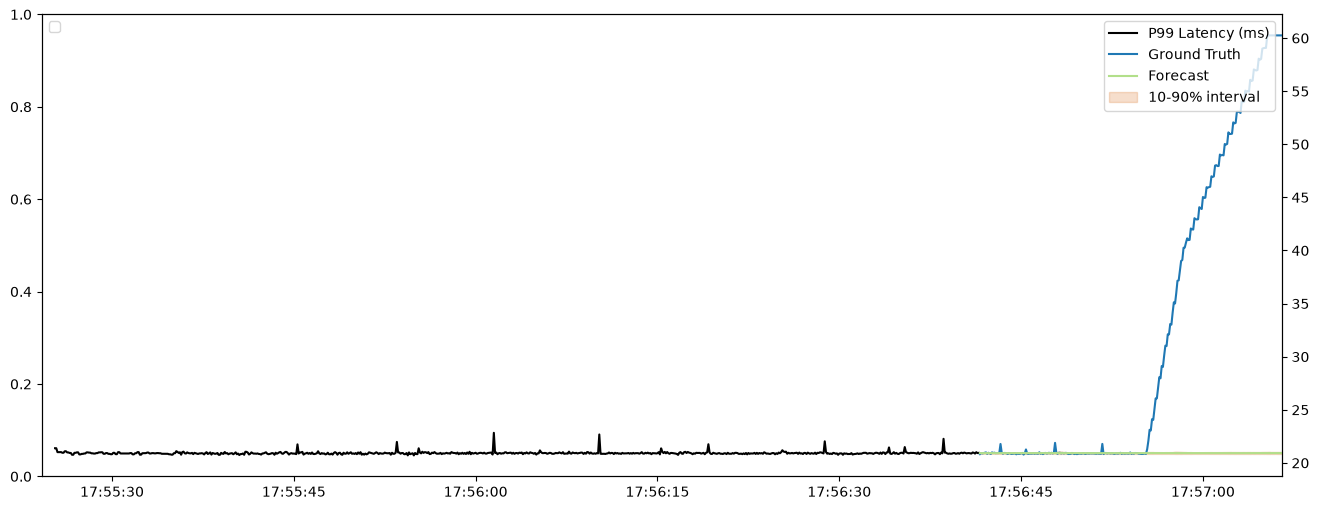

In [21]:
figure, laxis = matplotlib.pyplot.subplots(figsize=(16, 6))
raxis = laxis.twinx()

laxis.set_prop_cycle(cycler(color=["#E69F00", "#56B4E9", "#009E73", "#F0E442"]))

#laxis.plot(probe_data_frame['cpu-cycles'] / 1e3,     label="Kcpu-cycles/100ms")
#laxis.plot(probe_data_frame['ref-cpu-cycles'] / 1e3, label="Kref-cycles/100ms")
#laxis.plot(probe_data_frame['instructions'] / 1e3,   label="Kinstructions/100ms")
#laxis.plot(probe_data_frame['cache-misses'],         label="cache-misses/100ms")

raxis.plot(train_data_frame['timestamp'],    train_data_frame['p99_latency_ms'],  label="P99 Latency (ms)", color="#000000")
raxis.plot(test_data_frame['timestamp'],     test_data_frame['p99_latency_ms'],  label="Ground Truth", color="#1f78b4")
raxis.plot(forecast_data_frame['timestamp'], forecast_data_frame['predictions'], label="Forecast", color="#b2df8a")
raxis.fill_between(
    forecast_data_frame['timestamp'],
    forecast_data_frame['0.1'],
    forecast_data_frame['0.9'],
    color="#D55E00",
    alpha=0.2,
    label="10-90% interval",
)

# twinx() shares the x-axis, so whichever axes autoscales last wins the shared xlim. Pin it
# explicitly to the full data range (probe history through the end of the forecast) so the
# P99 series doesn't get clipped to just its own plotted span.
laxis.set_xlim(probe_data_frame.index.min(), forecast_data_frame['timestamp'].max())

laxis.legend(loc="upper left")
raxis.legend(loc="upper right")